In [22]:
import os
import sys
import tempfile
import random
import logging
from glob import glob
from typing import List, Dict, Tuple, Optional
from PIL import Image

import monai
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

from monai.data import Dataset, CacheDataset
from monai.transforms import (
    Compose,
    LoadImageD,
    EnsureChannelFirstD,
    ScaleIntensityRangeD,
    ResizeD,
    EnsureTypeD,
    RandFlipD,
    RandRotateD,
    RandAffineD,
    MapTransform,
)
from monai.networks.nets import densenet121
from monai.visualize import GradCAM
from monai.config import print_config
from monai.engines import SupervisedTrainer
from monai.handlers import StatsHandler
from monai.inferers import SimpleInferer

# For robust AUC
from sklearn.metrics import roc_auc_score
print_config()

MONAI version: 1.5.dev2504
Numpy version: 1.26.4
Pytorch version: 2.9.1+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 5787bf9b5b634509248b453c241610d9d9ee9314
MONAI __file__: /home/<username>/MonAi/my_torch_env/lib/python3.12/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: 5.4.5
Nibabel version: 5.3.3
scikit-image version: 0.26.0
scipy version: 1.17.0
Pillow version: 12.0.0
Tensorboard version: 2.20.0
gdown version: 5.2.1
TorchVision version: 0.24.1
tqdm version: 4.67.1
lmdb version: 1.7.5
psutil version: 7.2.1
pandas version: 2.3.3
einops version: 0.8.1
transformers version: 4.57.5
mlflow version: 3.8.1
pynrrd version: 1.1.3
clearml version: 2.1.2

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installing-the-recommended-dependencies



In [23]:
image_df = pd.read_csv("data/BBox_List_2017.csv")
patient_df = pd.read_csv("data/Data_Entry_2017.csv")

In [24]:
patient_df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [25]:
image_df.head()

,Image Index,Finding Label,Bbox [x,y,w,h],Unnamed: 6,Unnamed: 7,Unnamed: 8
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441,NaN,NaN,NaN
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525,NaN,NaN,NaN
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153,NaN,NaN,NaN
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034,NaN,NaN,NaN
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695,NaN,NaN,NaN


In [26]:
image_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Image Index    984 non-null    object 
 1   Finding Label  984 non-null    object 
 2   Bbox [x        984 non-null    float64
 3   y              984 non-null    float64
 4   w              984 non-null    float64
 5   h]             984 non-null    float64
 6   Unnamed: 6     0 non-null      float64
 7   Unnamed: 7     0 non-null      float64
 8   Unnamed: 8     0 non-null      float64
dtypes: float64(7), object(2)
memory usage: 69.3+ KB


In [27]:
patient_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Gender               112120 non-null  object 
 6   View Position                112120 non-null  object 
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
 11  Unnamed: 11                  0 non-null       float64
dtypes: float64(3), int64(5), object(4)
memory usage: 10.3+ MB


In [28]:
all_image_paths = {os.path.basename(x): x for x in 
                   glob(os.path.join('data',  'images*', '*', '*.png'))}

patient_df['image_path'] = patient_df['Image Index'].map(all_image_paths.get)

In [29]:
# patient_df = (
#     patient_df
#     .assign(labels=patient_df["Finding Labels"].str.split("|"))
#     .explode("labels")
# )

patient_df.rename(columns={"Finding Labels":"labels"}, inplace=True)

In [30]:
patient_df.drop(["Unnamed: 11"], axis=1, inplace=True)
image_df.drop(["Unnamed: 6", "Unnamed: 7", "Unnamed: 8"], axis=1, inplace=True)

patient_df.shape, image_df.shape

((112120, 12), (984, 6))

In [31]:
patient_df.rename(columns={"OriginalImage[Width": "OriginalImage[Width]", 
                           "Height]":"OriginalImage[Height]", "OriginalImagePixelSpacing[x":"OriginalImagePixelSpacing[x]",
                           "y]":"OriginalImagePixelSpacing[y]"}, inplace=True)

image_df.rename(columns={"Bbox [x":"Bbox [x]", "y":"Bbox [y]", "w":"Bbox [w]", "h]":"Bbox [h]",
                          "Finding Label":"labels"}, inplace=True)


In [32]:
df_merged = pd.merge(
    image_df,
    patient_df,
    on="Image Index",
    # how="left"   # inner, left, right, outer
)
df_merged.head()

,Image Index,labels_x,Bbox [x],Bbox [y],Bbox [w],Bbox [h],labels_y,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width],OriginalImage[Height],OriginalImagePixelSpacing[x],OriginalImagePixelSpacing[y],image_path
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441,Atelectasis,8,13118,69,M,PA,2992,2991,0.143,0.143,data/images_006/images/00013118_008.png
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525,Atelectasis|Effusion|Mass,7,14716,53,M,AP,3056,2544,0.139,0.139,data/images_007/images/00014716_007.png
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153,Atelectasis,9,29817,67,F,AP,3056,2544,0.139,0.139,data/images_012/images/00029817_009.png
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034,Atelectasis|Cardiomegaly|Consolidation,1,14687,51,M,AP,2500,2048,0.168,0.168,data/images_007/images/00014687_001.png
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695,Atelectasis,1,17877,75,F,AP,2500,2048,0.168,0.168,data/images_008/images/00017877_001.png


In [33]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Image Index                   984 non-null    object 
 1   labels_x                      984 non-null    object 
 2   Bbox [x]                      984 non-null    float64
 3   Bbox [y]                      984 non-null    float64
 4   Bbox [w]                      984 non-null    float64
 5   Bbox [h]                      984 non-null    float64
 6   labels_y                      984 non-null    object 
 7   Follow-up #                   984 non-null    int64  
 8   Patient ID                    984 non-null    int64  
 9   Patient Age                   984 non-null    int64  
 10  Patient Gender                984 non-null    object 
 11  View Position                 984 non-null    object 
 12  OriginalImage[Width]          984 non-null    int64  
 13  Origi

In [29]:
patient_df["labels"].value_counts()

labels
No Finding                                                                   18000
Infiltration                                                                  9547
Atelectasis                                                                   4215
Effusion                                                                      3955
Nodule                                                                        2705
                                                                             ...  
Atelectasis|Consolidation|Effusion|Infiltration|Nodule|Pleural_Thickening        1
Atelectasis|Consolidation|Edema|Effusion|Pleural_Thickening                      1
Consolidation|Effusion|Mass|Nodule|Pleural_Thickening|Atelectasis                1
Effusion|Mass|Pneumonia|Pneumothorax                                             1
Atelectasis|Cardiomegaly|Edema|Infiltration                                      1
Name: count, Length: 792, dtype: int64

In [14]:
patient_df = patient_df[~patient_df["labels"].str.contains('Hernia')]

In [15]:
patient_df = pd.concat([patient_df[patient_df["labels"]!="No Finding"], 
patient_df[patient_df["labels"]=="No Finding"].sample(n=18000)], ignore_index=True)

patient_df.shape

(69532, 12)

In [17]:
patient_labels = (
    patient_df
    .assign(labels=patient_df["labels"].str.split("|"))
    .explode("labels")
)
patient_labels["labels"].value_counts()

labels
Infiltration          19861
No Finding            18000
Effusion              13296
Atelectasis           11519
Nodule                 6321
Mass                   5757
Pneumothorax           5293
Consolidation          4663
Pleural_Thickening     3377
Cardiomegaly           2769
Emphysema              2512
Edema                  2300
Fibrosis               1678
Pneumonia              1428
Name: count, dtype: int64

In [22]:
LABELS = [
    "No Finding",
    "Infiltration",
    "Effusion",
    "Atelectasis",
    "Nodule",
    "Mass",
    "Pneumothorax",
    "Consolidation",
    "Pleural_Thickening",
    "Cardiomegaly",
    "Emphysema",
    "Edema",
    "Fibrosis",
    "Pneumonia"
]

patient_df_list = []
for col in LABELS:
    patient_df_list.append(patient_df[patient_df["labels"].str.contains(col)].sample(1420))

In [24]:
patient_df_sampled = pd.concat(patient_df_list)
patient_df_sampled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19880 entries, 62999 to 44228
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Image Index                   19880 non-null  object 
 1   labels                        19880 non-null  object 
 2   Follow-up #                   19880 non-null  int64  
 3   Patient ID                    19880 non-null  int64  
 4   Patient Age                   19880 non-null  int64  
 5   Patient Gender                19880 non-null  object 
 6   View Position                 19880 non-null  object 
 7   OriginalImage[Width]          19880 non-null  int64  
 8   OriginalImage[Height]         19880 non-null  int64  
 9   OriginalImagePixelSpacing[x]  19880 non-null  float64
 10  OriginalImagePixelSpacing[y]  19880 non-null  float64
 11  image_path                    19880 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 2.0+ MB


In [25]:
DATA_PATH = "data/Patient_data.csv"
patient_df_sampled.to_csv(DATA_PATH, index=False)

In [5]:
# -----------------------------
# 0) Label setup (15 classes)
# -----------------------------
LABELS = [
    "No Finding",
    "Infiltration",
    "Effusion",
    "Atelectasis",
    "Nodule",
    "Mass",
    "Pneumothorax",
    "Consolidation",
    "Pleural_Thickening",
    "Cardiomegaly",
    "Emphysema",
    "Edema",
    "Fibrosis",
    "Pneumonia"
]
label_to_idx = {l: i for i, l in enumerate(LABELS)}
NUM_CLASSES = len(LABELS)

In [6]:
# -----------------------------
# 1) Utilities: labels + split
# -----------------------------
def multilabel_to_multihot(label_str: str) -> np.ndarray:
    """
    Converts pipe-separated multi-label string -> multi-hot float vector.
    Robust "No Finding" handling:
      - if empty/NaN -> No Finding = 1
      - if only "No Finding" -> No Finding = 1
      - if any disease labels present -> No Finding = 0
    """
    y = np.zeros(NUM_CLASSES, dtype=np.float32)

    if pd.isna(label_str) or str(label_str).strip() == "":
        y[label_to_idx["No Finding"]] = 1.0
        return y

    parts = [p.strip() for p in str(label_str).split("|") if p.strip()]
    # collect known disease labels excluding No Finding
    known_diseases = [p for p in parts if p in label_to_idx and p != "No Finding"]

    if len(known_diseases) == 0:
        # if there are no disease labels, treat as No Finding
        y[label_to_idx["No Finding"]] = 1.0
        return y

    for p in known_diseases:
        y[label_to_idx[p]] = 1.0

    # ensure No Finding = 0 when any disease label exists
    y[label_to_idx["No Finding"]] = 0.0
    return y


def make_items_from_csv(csv_path: str) -> List[Dict]:
    df = pd.read_csv(csv_path)
    df = df.sample(frac=1)
    if "image_path" not in df.columns or "labels" not in df.columns:
        raise ValueError("CSV must have columns: image_path, labels")

    items = []
    for _, row in df.iterrows():
        img_path = str(row["image_path"])
        y = multilabel_to_multihot(row["labels"])
        items.append({"image": img_path, "label": y})
    return items


def train_val_split(
    items: List[Dict], val_frac: float = 0.1, seed: int = 42
) -> Tuple[List[Dict], List[Dict]]:
    rng = random.Random(seed)
    rng.shuffle(items)
    n_val = max(1, int(len(items) * val_frac))
    return items[n_val:], items[:n_val]

In [7]:
multilabel_to_multihot("Atelectasis|Consolidation|Edema|Effusion|Infiltration|Pneumonia")

array([0., 1., 1., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1.],
      dtype=float32)

In [8]:
# -----------------------------
# 2) MONAI transform helpers
# -----------------------------
class ToGrayscaleD(MapTransform):
    """
    Ensures image is 1-channel. If loaded as RGB/multi-channel, converts by mean over channels.
    Expects channel-first [C,H,W].
    """

    def __call__(self, data):
        d = dict(data)
        x = d["image"]
        # x can be numpy or torch
        c = x.shape[0]
        if c > 1:
            x = x.mean(axis=0, keepdims=True)
        d["image"] = x
        return d


def get_transforms(img_size=(320, 320)):
    # Deterministic preprocessing (safe to cache)
    pre_tfms = Compose(
        [
            LoadImageD(keys="image", image_only=True),
            EnsureChannelFirstD(keys="image"),  # -> [C,H,W] or [1,H,W]
            ToGrayscaleD(keys="image"),
            # If your images are already float [0..1], adjust a_min/a_max accordingly
            ScaleIntensityRangeD(
                keys="image", a_min=0, a_max=255, b_min=0.0, b_max=1.0, clip=True
            ),
            ResizeD(keys="image", spatial_size=img_size),
            EnsureTypeD(keys=("image", "label")),
        ]
    )

    # Random augmentations (DO NOT cache these)
    aug_tfms = Compose(
        [
            RandFlipD(keys="image", prob=0.5, spatial_axis=1),
            RandRotateD(keys="image", range_x=np.pi / 36, prob=0.3),
            RandAffineD(keys="image", prob=0.2, translate_range=(10, 10)),
            EnsureTypeD(keys=("image", "label")),
        ]
    )

    # Validation: deterministic only
    val_tfms = pre_tfms
    return pre_tfms, aug_tfms, val_tfms


def build_loaders(
    csv_path: str,
    batch_size: int = 32,
    num_workers: int = 8,
    cache_rate: float = 0.2,
    val_frac: float = 0.1,
    seed: int = 42,
    img_size=(320, 320),
):
    items = make_items_from_csv(csv_path)
    train_items, val_items = train_val_split(items, val_frac=val_frac, seed=seed)

    pre_tfms, aug_tfms, val_tfms = get_transforms(img_size=img_size)

    # Cache only deterministic preprocessing
    train_cached = CacheDataset(
        data=train_items,
        transform=pre_tfms,
        cache_rate=cache_rate,
        num_workers=num_workers,
    )
    # Apply augmentation after cache
    train_ds = Dataset(data=train_cached, transform=aug_tfms)

    # Val can be cached too (deterministic)
    val_ds = CacheDataset(
        data=val_items,
        transform=val_tfms,
        cache_rate=min(1.0, cache_rate),
        num_workers=num_workers,
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

    return train_loader, val_loader, train_items, val_items


In [9]:
# -----------------------------
# 3) Metrics: robust per-class AUC
# -----------------------------
def compute_macro_auc(
    y_true: np.ndarray, y_prob: np.ndarray, eps: float = 1e-8
) -> Tuple[float, np.ndarray, np.ndarray]:
    """
    y_true: [N,C] multi-hot (0/1)
    y_prob: [N,C] probabilities in [0,1]
    Returns:
      macro_auc (mean over valid classes),
      per_class_auc [C] with NaN for invalid classes,
      valid_mask [C] bool (True = class used)
    """
    C = y_true.shape[1]
    per_auc = np.full((C,), np.nan, dtype=np.float32)
    valid = np.zeros((C,), dtype=bool)

    for c in range(C):
        yt = y_true[:, c]
        yp = y_prob[:, c]
        # Need both positive and negative samples for ROC AUC
        if yt.max() == yt.min():
            continue
        try:
            per_auc[c] = roc_auc_score(yt, yp)
            valid[c] = True
        except Exception:
            # keep NaN
            pass

    if valid.any():
        macro = float(np.nanmean(per_auc))
    else:
        macro = float("nan")
    return macro, per_auc, valid


# -----------------------------
# 4) Loss: pos_weight for imbalance
# -----------------------------
def compute_pos_weight_from_items(train_items: List[Dict]) -> torch.Tensor:
    """
    pos_weight for BCEWithLogitsLoss:
      pos_weight[c] = (#neg[c] / #pos[c])
    """
    y = np.stack([it["label"] for it in train_items], axis=0)  # [N,C]
    pos = y.sum(axis=0)  # [C]
    neg = y.shape[0] - pos
    # pos_weight = np.sqrt(neg / (pos + 1e-5))
    pos_weight = neg / (pos + 1e-8)
    return torch.tensor(pos_weight, dtype=torch.float32)

In [10]:
csv_path = "data/Patient_data.csv"
out_path = "outputs/checkpoints/best_cxr_multilabel_2.pt"
epochs = 15
batch_size = 32
lr = 3e-4
num_workers = 8
cache_rate = 0.3
val_frac = 0.1
seed = 43
img_size =(320, 320)
amp = True
use_pos_weight = True

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [12]:
train_loader, val_loader, train_items, val_items = build_loaders(
    csv_path=csv_path,
    batch_size=batch_size,
    num_workers=num_workers,
    cache_rate=cache_rate,
    val_frac=val_frac,
    seed=seed,
    img_size=img_size,
)

Loading dataset:   4%|▎         | 682/18773 [00:03<01:22, 218.16it/s]

Loading dataset: 100%|██████████| 2085/2085 [00:09<00:00, 210.58it/s]


In [15]:
model = densenet121(spatial_dims=2, in_channels=1, out_channels=NUM_CLASSES).to(
        device
    )

In [16]:
if use_pos_weight:
    pos_weight = compute_pos_weight_from_items(train_items).to(device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
else:
    loss_fn = nn.BCEWithLogitsLoss()

opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
scaler = torch.amp.GradScaler(enabled=(amp and device.type == "cuda"), device=device)

In [17]:
pos_weight

tensor([ 2.8689,  2.4937,  4.2359,  5.0271,  9.9691, 11.1019, 12.1662, 13.8011,
        19.7421, 23.8132, 26.6653, 29.3634, 41.1976, 46.9165], device='cuda:0')

In [ ]:
max_epochs = 5

logging.basicConfig(stream=sys.stdout, level=logging.INFO)
trainer = SupervisedTrainer(
    device=device,
    max_epochs=max_epochs,
    train_data_loader=train_loader,
    network=model,
    optimizer=opt,
    loss_function=loss_fn,
    inferer=SimpleInferer(),
    train_handlers=StatsHandler(),
)

In [19]:
trainer.run()

INFO:ignite.engine.engine.SupervisedTrainer:Engine run resuming from iteration 0, epoch 0 until 5 epochs
2026-01-22 05:12:35,054 - INFO - Epoch: 1/5, Iter: 1/1956 -- loss: 1.3027 
2026-01-22 05:12:35,194 - INFO - Epoch: 1/5, Iter: 2/1956 -- loss: 1.2244 


ignoring non-scalar output in StatsHandler, make sure `output_transform(engine.state.output)` returns a scalar or dictionary of key and scalar pairs to avoid this warning. image:<class 'monai.data.meta_tensor.MetaTensor'>
ignoring non-scalar output in StatsHandler, make sure `output_transform(engine.state.output)` returns a scalar or dictionary of key and scalar pairs to avoid this warning. label:<class 'monai.data.meta_tensor.MetaTensor'>
ignoring non-scalar output in StatsHandler, make sure `output_transform(engine.state.output)` returns a scalar or dictionary of key and scalar pairs to avoid this warning. pred:<class 'monai.data.meta_tensor.MetaTensor'>


2026-01-22 05:12:35,323 - INFO - Epoch: 1/5, Iter: 3/1956 -- loss: 1.2614 
2026-01-22 05:12:35,461 - INFO - Epoch: 1/5, Iter: 4/1956 -- loss: 1.0570 
2026-01-22 05:12:35,597 - INFO - Epoch: 1/5, Iter: 5/1956 -- loss: 1.1920 
2026-01-22 05:12:35,731 - INFO - Epoch: 1/5, Iter: 6/1956 -- loss: 1.2741 
2026-01-22 05:12:35,871 - INFO - Epoch: 1/5, Iter: 7/1956 -- loss: 1.2219 
2026-01-22 05:12:36,024 - INFO - Epoch: 1/5, Iter: 8/1956 -- loss: 1.4410 
2026-01-22 05:12:36,165 - INFO - Epoch: 1/5, Iter: 9/1956 -- loss: 1.2144 
2026-01-22 05:12:36,303 - INFO - Epoch: 1/5, Iter: 10/1956 -- loss: 1.5319 
2026-01-22 05:12:36,451 - INFO - Epoch: 1/5, Iter: 11/1956 -- loss: 1.4339 
2026-01-22 05:12:36,600 - INFO - Epoch: 1/5, Iter: 12/1956 -- loss: 1.4105 
2026-01-22 05:12:36,747 - INFO - Epoch: 1/5, Iter: 13/1956 -- loss: 1.1115 
2026-01-22 05:12:36,887 - INFO - Epoch: 1/5, Iter: 14/1956 -- loss: 0.9734 
2026-01-22 05:12:37,027 - INFO - Epoch: 1/5, Iter: 15/1956 -- loss: 1.2831 
2026-01-22 05:12:37

In [40]:
torch.save(
            {
                "model": model.state_dict(),
                "labels": LABELS,
                "img_size": img_size,
                "csv": os.path.abspath(csv_path),
            },
            out_path,
        )

In [34]:
# -----------------------------
# 6) Inference + Grad-CAM + overlay plotting
# -----------------------------

def disable_inplace_relu(m):
    for mod in m.modules():
        if isinstance(mod, nn.ReLU):
            mod.inplace = False

def load_checkpoint(ckpt_path: str, device=None):
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ckpt = torch.load(ckpt_path, map_location=device)
    model = densenet121(spatial_dims=2, in_channels=1, out_channels=NUM_CLASSES).to(
        device
    )
    model.load_state_dict(ckpt["model"])
    disable_inplace_relu(model)
    model.eval()
    img_size = tuple(ckpt.get("img_size", (320, 320)))
    return model, ckpt.get("labels", LABELS), img_size, device


def build_single_image_preprocess(img_size=(320, 320)):
    # Same deterministic preprocessing used in training/val
    pre_tfms = Compose(
        [
            LoadImageD(keys="image", image_only=True),
            EnsureChannelFirstD(keys="image"),
            ToGrayscaleD(keys="image"),
            ScaleIntensityRangeD(
                keys="image", a_min=0, a_max=255, b_min=0.0, b_max=1.0, clip=True
            ),
            ResizeD(keys="image", spatial_size=img_size),
            EnsureTypeD(keys="image", track_meta=False),
        ]
    )
    return pre_tfms


def infer_with_gradcam(
    model: torch.nn.Module,
    image_path: str,
    class_idx: int,
    img_size=(320, 320),
    target_layers: str = "features",
):
    """
    Returns:
      probs: [C] float numpy
      cam:   [h,w] float numpy (0..1), typically lower-res than input
      img:   [H,W] float numpy (0..1) preprocessed image
    """
    device = next(model.parameters()).device
    pre = build_single_image_preprocess(img_size=img_size)

    sample = {"image": image_path}
    x = pre(sample)["image"]  # [1,H,W] torch tensor
    x = x.unsqueeze(0).to(device)  # [1,1,H,W]

    # Probabilities (no-grad)
    with torch.no_grad():
        logits = model(x)
        probs = torch.sigmoid(logits)[0].detach().cpu().numpy()

    # Grad-CAM needs gradients (do NOT wrap in torch.no_grad)
    cam_gen = GradCAM(nn_module=model, target_layers=target_layers)
    cam = cam_gen(x, class_idx=class_idx)  # [1,1,h,w]
    cam = cam[0, 0].detach().cpu().numpy()
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    img = x[0, 0].detach().cpu().numpy()  # [H,W] 0..1
    return probs, cam, img


def overlay_cam(img: np.ndarray, cam: np.ndarray, alpha: float = 0.35) -> np.ndarray:
    """
    img: [H,W] float 0..1
    cam: [h,w] float 0..1
    output: [H,W] float 0..1 (simple blend; for nicer visuals use colormap overlay)
    """
    if cam.shape != img.shape:
        cam_t = torch.tensor(cam)[None, None, ...]
        cam_rs = torch.nn.functional.interpolate(
            cam_t, size=img.shape, mode="bilinear", align_corners=False
        )[0, 0].numpy()
    else:
        cam_rs = cam

    out = (1 - alpha) * img + alpha * cam_rs
    return np.clip(out, 0.0, 1.0)


def visualize_gradcam(image_path: str, ckpt_path: str, class_name: str):
    import matplotlib.pyplot as plt

    model, labels, img_size, device = load_checkpoint(ckpt_path)
    if class_name not in label_to_idx:
        raise ValueError(f"class_name must be one of: {labels}")

    class_idx = label_to_idx[class_name]
    probs, cam, img = infer_with_gradcam(
        model=model,
        image_path=image_path,
        class_idx=class_idx,
        img_size=img_size,
        target_layers="features",
    )

    blended = overlay_cam(img, cam, alpha=0.35)

    topk = np.argsort(-probs)[:5]
    print("Top-5 predicted labels:")
    for i in topk:
        print(f"  {labels[i]:>20s}: {probs[i]:.4f}")

    plt.figure()
    plt.title(f"Grad-CAM blend for: {class_name} (p={probs[class_idx]:.3f})")
    plt.imshow(blended, cmap="gray")
    plt.axis("off")
    plt.show()

    # Optional: show CAM heatmap itself
    plt.figure()
    plt.title("Grad-CAM heatmap")
    plt.imshow(img, cmap="gray")
    plt.imshow(
        torch.nn.functional.interpolate(
            torch.tensor(cam)[None, None, ...],
            size=img.shape,
            mode="bilinear",
            align_corners=False,
        )[0, 0].numpy(),
        cmap="jet",
        alpha=0.4,
    )
    plt.axis("off")
    plt.show()



In [35]:
df_merged.head()

,Image Index,labels_x,Bbox [x],Bbox [y],Bbox [w],Bbox [h],labels_y,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width],OriginalImage[Height],OriginalImagePixelSpacing[x],OriginalImagePixelSpacing[y],image_path
0,00013118_008.png,Atelectasis,225.084746,547.019217,86.779661,79.186441,Atelectasis,8,13118,69,M,PA,2992,2991,0.143,0.143,data/images_006/images/00013118_008.png
1,00014716_007.png,Atelectasis,686.101695,131.543498,185.491525,313.491525,Atelectasis|Effusion|Mass,7,14716,53,M,AP,3056,2544,0.139,0.139,data/images_007/images/00014716_007.png
2,00029817_009.png,Atelectasis,221.830508,317.053115,155.118644,216.949153,Atelectasis,9,29817,67,F,AP,3056,2544,0.139,0.139,data/images_012/images/00029817_009.png
3,00014687_001.png,Atelectasis,726.237288,494.951420,141.016949,55.322034,Atelectasis|Cardiomegaly|Consolidation,1,14687,51,M,AP,2500,2048,0.168,0.168,data/images_007/images/00014687_001.png
4,00017877_001.png,Atelectasis,660.067797,569.780787,200.677966,78.101695,Atelectasis,1,17877,75,F,AP,2500,2048,0.168,0.168,data/images_008/images/00017877_001.png


In [36]:
df_merged["labels_x"].value_counts()

labels_x
Atelectasis     180
Effusion        153
Cardiomegaly    146
Infiltrate      123
Pneumonia       120
Pneumothorax     98
Mass             85
Nodule           79
Name: count, dtype: int64

In [37]:
tmp_df = df_merged[df_merged["labels_x"]=="Atelectasis"]

Top-5 predicted labels:
             Emphysema: 0.8802
          Pneumothorax: 0.8338
    Pleural_Thickening: 0.6446
              Effusion: 0.6166
                  Mass: 0.5429


Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


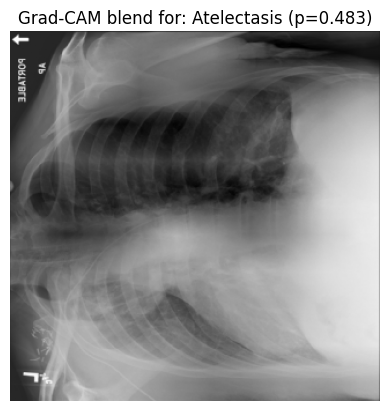

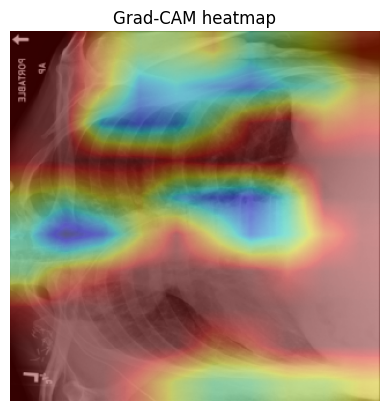

In [43]:
i=1
img_path = tmp_df.iloc[i]["image_path"]
cls_label = tmp_df.iloc[i]["labels_x"]
visualize_gradcam(
        image_path=img_path,
        ckpt_path=out_path,
        class_name=cls_label,
    )

In [45]:
tmp_df.iloc[i]["labels_y"]

'Atelectasis|Effusion|Mass'

In [49]:
# ---- validate ----
model, labels, img_size, device = load_checkpoint(out_path)
model.eval()
probs_all = []
y_all = []
with torch.no_grad():
    for batch in val_loader:
        x = batch["image"].to(device)
        y = batch["label"].to(device)
        with torch.amp.autocast("cuda",enabled=(amp and device.type == "cuda")):
            logits = model(x)
            probs = torch.sigmoid(logits)

        probs_all.append(probs.detach().cpu())
        y_all.append(y.detach().cpu())

probs_all = torch.cat(probs_all, dim=0).numpy()
y_all = torch.cat(y_all, dim=0).numpy()

In [50]:
y_all.shape, probs_all.shape

((6953, 14), (6953, 14))

In [51]:
probs_all = np.where(probs_all > 0.5, 1, 0)

In [52]:
for y_true_i, y_pred_i in zip(y_all, probs_all):
    print(np.nonzero(y_true_i), np.nonzero(y_pred_i))
    break

(array([2, 3]),) (array([2, 3, 6, 7]),)


In [53]:
from sklearn.metrics import classification_report

print(classification_report(y_all, probs_all, target_names=labels))

                    precision    recall  f1-score   support

        No Finding       0.47      0.41      0.44      1825
      Infiltration       0.45      0.34      0.39      1949
          Effusion       0.26      0.91      0.40      1344
       Atelectasis       0.25      0.66      0.36      1136
            Nodule       0.19      0.24      0.21       616
              Mass       0.14      0.72      0.23       586
      Pneumothorax       0.10      0.93      0.17       540
     Consolidation       0.10      0.74      0.18       435
Pleural_Thickening       0.06      0.86      0.12       360
      Cardiomegaly       0.12      0.54      0.20       247
         Emphysema       0.05      0.92      0.10       250
             Edema       0.11      0.64      0.18       239
          Fibrosis       0.05      0.73      0.09       195
         Pneumonia       0.03      0.60      0.06       122

         micro avg       0.14      0.59      0.23      9844
         macro avg       0.17      0.6

Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.


In [54]:
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, f1_score, roc_curve, precision_recall_curve

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

@torch.no_grad()
def collect_val_outputs(model, val_loader, device):
    model.eval()
    probs_all, y_all = [], []
    for batch in val_loader:
        x = batch["image"].to(device)
        y = batch["label"].cpu().numpy()
        logits = model(x).detach().cpu().numpy()
        probs = sigmoid(logits)
        probs_all.append(probs)
        y_all.append(y)
    return np.concatenate(probs_all, axis=0), np.concatenate(y_all, axis=0)

def per_class_metrics_and_thresholds(y_true, y_prob, labels, method="f1", default_thr=0.5):
    """
    method:
      - "f1": choose threshold maximizing F1 on validation (common for improving report)
      - "youden": choose threshold maximizing (tpr - fpr) from ROC
      - "pr_f1": same as f1 but uses PR curve thresholds (often smoother)
    """
    C = y_true.shape[1]
    auc = np.full(C, np.nan, dtype=np.float32)
    ap  = np.full(C, np.nan, dtype=np.float32)
    thr = np.full(C, default_thr, dtype=np.float32)
    valid = np.zeros(C, dtype=bool)

    for c in range(C):
        yt = y_true[:, c]
        yp = y_prob[:, c]
        if yt.max() == yt.min():  # all 0 or all 1 -> cannot compute meaningful curves
            continue

        valid[c] = True
        auc[c] = roc_auc_score(yt, yp)
        ap[c]  = average_precision_score(yt, yp)

        if method == "youden":
            fpr, tpr, thresholds = roc_curve(yt, yp)
            j = tpr - fpr
            thr[c] = thresholds[np.argmax(j)]

        elif method in ("f1", "pr_f1"):
            # Sweep thresholds to maximize F1
            if method == "pr_f1":
                p, r, thresholds = precision_recall_curve(yt, yp)
                # precision_recall_curve returns thresholds of length-1 of p/r
                # We'll compute F1 for those points
                f1 = (2 * p[:-1] * r[:-1]) / (p[:-1] + r[:-1] + 1e-12)
                thr[c] = thresholds[np.argmax(f1)]
            else:
                # dense sweep 0..1
                candidates = np.linspace(0.01, 0.99, 99)
                f1s = [f1_score(yt, (yp >= t).astype(int), zero_division=0) for t in candidates]
                thr[c] = candidates[int(np.argmax(f1s))]

        else:
            raise ValueError("method must be one of: f1, youden, pr_f1")

    return auc, ap, thr, valid

def apply_thresholds(y_prob, thresholds):
    return (y_prob >= thresholds[None, :]).astype(np.int32)

def enforce_topk(y_prob, k=1, min_thr=None):
    """
    Ensures at least k labels predicted per sample (useful to avoid 'no predicted labels' warnings).
    If min_thr is set, we only apply top-k when no label exceeds min_thr.
    """
    y_pred = np.zeros_like(y_prob, dtype=np.int32)
    if min_thr is None:
        idx = np.argsort(-y_prob, axis=1)[:, :k]
        rows = np.arange(y_prob.shape[0])[:, None]
        y_pred[rows, idx] = 1
    else:
        # if any above min_thr -> threshold normally, else top-k
        thr_pred = (y_prob >= min_thr).astype(np.int32)
        need = thr_pred.sum(axis=1) == 0
        y_pred[:] = thr_pred
        if np.any(need):
            idx = np.argsort(-y_prob[need], axis=1)[:, :k]
            rows = np.arange(idx.shape[0])[:, None]
            y_pred_need = np.zeros_like(y_prob[need], dtype=np.int32)
            y_pred_need[rows, idx] = 1
            y_pred[need] = y_pred_need
    return y_pred

In [55]:
# ---------------------------
# Example usage
# ---------------------------
probs_val, y_val = collect_val_outputs(model, val_loader, device)

# Compute thresholds (try method="youden" first for clinically balanced operating point)
auc, ap, thr, valid = per_class_metrics_and_thresholds(y_val, probs_val, labels, method="youden")

# Optional: neutralize No Finding thresholding
thr[label_to_idx["No Finding"]] = 0.5

y_pred = apply_thresholds(probs_val, thr)
print(classification_report(y_val, y_pred, target_names=labels, zero_division=0))

# Print summary
print("macro ROC-AUC:", np.nanmean(auc))
print("macro PR-AUC :", np.nanmean(ap))

                    precision    recall  f1-score   support

        No Finding       0.47      0.41      0.44      1825
      Infiltration       0.39      0.53      0.45      1949
          Effusion       0.30      0.75      0.43      1344
       Atelectasis       0.28      0.57      0.37      1136
            Nodule       0.15      0.49      0.23       616
              Mass       0.15      0.65      0.25       586
      Pneumothorax       0.14      0.66      0.24       540
     Consolidation       0.12      0.63      0.21       435
Pleural_Thickening       0.08      0.72      0.14       360
      Cardiomegaly       0.09      0.73      0.16       247
         Emphysema       0.08      0.66      0.14       250
             Edema       0.08      0.82      0.15       239
          Fibrosis       0.06      0.65      0.10       195
         Pneumonia       0.03      0.86      0.05       122

         micro avg       0.16      0.59      0.26      9844
         macro avg       0.17      0.6